In [1]:
import numpy as np
import matplotlib.pyplot as plt

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux

from few.trajectory.resonancehandler import ResonanceHandler

from multispline.spline import CubicSpline

from few.waveform import FastKerrEccentricEquatorialFlux

In [84]:
m1 = 1e6
m2 = 1e2
m3 = 1e2    # Mass of the third-body perturber 
R = 50*m1 # Radius of the third body perturber

nu = m1*m2/(m1+m2)**2  # symmetric mass ratio
epsilon = m3*m1**2/R**3

a = 0.9  # This model supports a spinning primary compact object
p0 = 10.0
e0 = 0.8
xI0 = 1.0  # +1 for prograde, -1 for retrograde inspirals

T = 1  # duration of trajectory in years (as defined by few.utils.constants.YRSID_SI)

traj_pars = [m1, m2, a, p0, e0, xI0]

In [86]:
# Load the data for the jumps on the resonance surface (a=0.9, x=1)
jump_data = np.loadtxt("/Users/niels/Downloads/resonance-a09_x1_n1k2m-2.csv", delimiter=",")
G_E_im = CubicSpline(jump_data[:,1], jump_data[:,2])
G_L_im = CubicSpline(jump_data[:,1], jump_data[:,3])
G_Q_im = CubicSpline(jump_data[:,1], jump_data[:,4])

def G_E(e):
    return 0 + 1j*G_E_im(e)

def G_L(e):
    return 0 + 1j*G_L_im(e)

def G_Q(e):
    return 0 + 1j*G_Q_im(e)

In [87]:
def res_jumps_ELQ_n1k2m_2(a,e,x,q,omega_dot):
    n = 1; k=2; m=-2;

    # Calculate the resonance phase, chi, 
    chi = m*q[0] + k*q[1] + m*q[2]
    Gamma = n*omega_dot[0] + k*omega_dot[1] + m*omega_dot[2]

    # Mass ratio scaling
    coeff = epsilon/np.sqrt(nu)
    
    # Below we just include the s=+/-1 cases following Eq. (2.11) of https://arxiv.org/pdf/2205.04808
    delta_E = coeff*np.sqrt(2*np.pi/np.abs(Gamma))*(np.exp(np.sign(Gamma)*1j*np.pi/4 + 1j*chi)*G_E(e) + np.exp(np.sign(-Gamma)*1j*np.pi/4 - 1j*chi)*np.conj(G_E(e)))
    delta_L = coeff*np.sqrt(2*np.pi/np.abs(Gamma))*(np.exp(np.sign(Gamma)*1j*np.pi/4 + 1j*chi)*G_L(e) + np.exp(np.sign(-Gamma)*1j*np.pi/4 - 1j*chi)*np.conj(G_L(e)))
    delta_Q = coeff*np.sqrt(2*np.pi/np.abs(Gamma))*(np.exp(np.sign(Gamma)*1j*np.pi/4 + 1j*chi)*G_Q(e) + np.exp(np.sign(-Gamma)*1j*np.pi/4 - 1j*chi)*np.conj(G_Q(e)))                                         
    return np.real(delta_E), np.real(delta_L), np.real(delta_Q)

In [88]:
def Omega_phi_3rd_body(a,p,e,x):
    return 15**(-3/2)

The resonance surface is defined by 

$$\kappa_r\Omega_r + \kappa_\theta\Omega_\theta + \kappa_\phi \Omega_\phi + \kappa_f f = 0$$

where $f\equiv f(a,p,e,x)$

In [89]:
resonance_n1k2m_2 = {
    'kappa_r': 1,
    'kappa_theta': 2,
    'kappa_phi': -2,
    'jump_func': res_jumps_ELQ_n1k2m_2
}

resonance_n1k2m_2_third_body = {
    'kappa_r': 1,
    'kappa_theta': 2,
    'kappa_phi': -2,
    'jump_func': res_jumps_ELQ_n1k2m_2,
    'kappa_f': 1,
    'f_res': Omega_phi_3rd_body
}

In [90]:
res1 = ResonanceHandler([resonance_n1k2m_2])
res2 = ResonanceHandler([resonance_n1k2m_2,resonance_n1k2m_2_third_body])

In [91]:
# You can also instantiate this as EMRIInspiral(func="KerrEccEqFlux") to save an import.
traj_model = EMRIInspiral(func=KerrEccEqFlux, flux_output_convention="ELQ")
traj_model_res1 = EMRIInspiral(func=KerrEccEqFlux, resonance_handler=res1, flux_output_convention="ELQ")
traj_model_res2 = EMRIInspiral(func=KerrEccEqFlux, resonance_handler=res2, flux_output_convention="ELQ")

In [92]:
new_T = np.linspace(0,1.73611189e+07,20000)

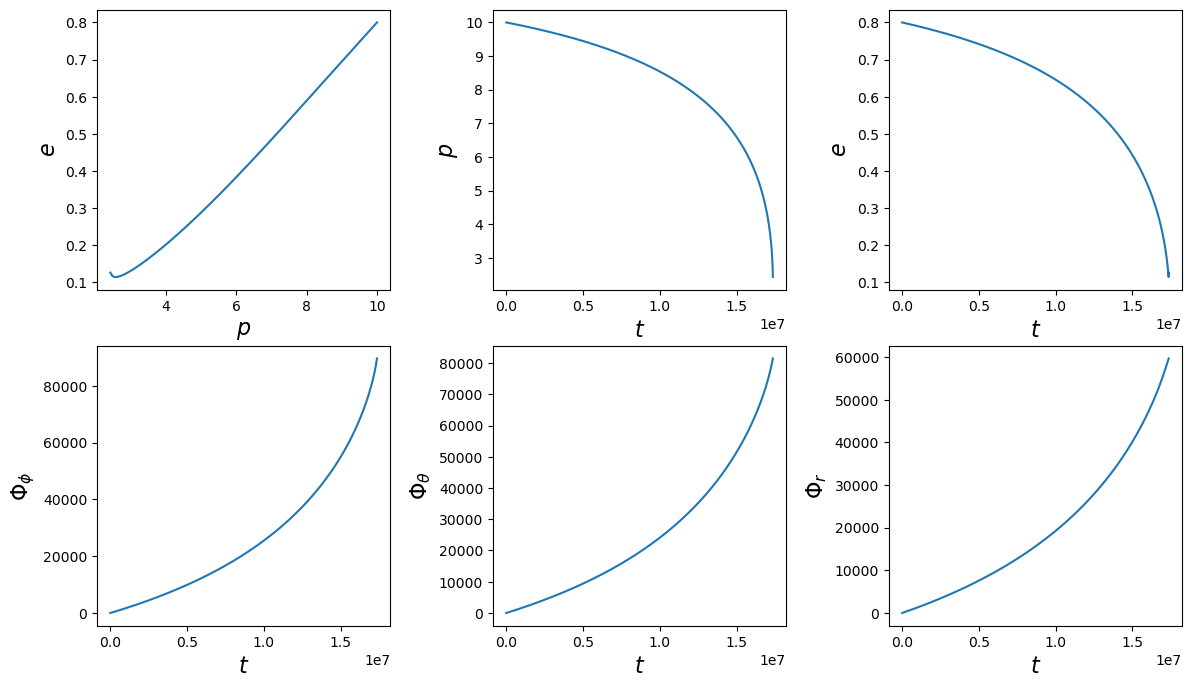

In [93]:
t, p, e, xI, Phi_phi, Phi_theta, Phi_r = traj_model(*traj_pars, T=T, upsample=True, new_t=new_T)
tRes1, pRes1, eRes1, xIRes1, Phi_phiRes1, Phi_thetaRes1, Phi_rRes1 = traj_model_res1(*traj_pars, T=T, upsample=True, new_t=new_T)
tRes2, pRes2, eRes2, xIRes2, Phi_phiRes2, Phi_thetaRes2, Phi_rRes2 = traj_model_res2(*traj_pars, T=T, upsample=True, new_t=new_T)


fig, axes = plt.subplots(2, 3)
plt.subplots_adjust(wspace=0.35)
fig.set_size_inches(14, 8)
axes = axes.ravel()

ylabels = [r"$e$", r"$p$", r"$e$", r"$\Phi_\phi$", r"$\Phi_\theta$", r"$\Phi_r$"]
xlabels = [r"$p$", r"$t$", r"$t$", r"$t$", r"$t$", r"$t$"]
ys = [eRes2, pRes2, eRes2, Phi_phiRes2, Phi_thetaRes2, Phi_rRes2]
xs = [pRes2, tRes2, tRes2, tRes2, tRes2, tRes2]

for i, (ax, x, y, xlab, ylab) in enumerate(zip(axes, xs, ys, xlabels, ylabels)):
    ax.plot(x, y)
    ax.set_xlabel(xlab, fontsize=16)
    ax.set_ylabel(ylab, fontsize=16)

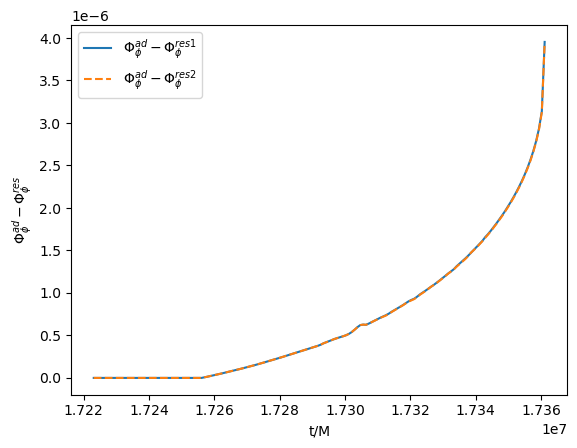

In [94]:
plt.plot(t[2*9920:],(Phi_phi-Phi_phiRes1)[2*9920:])
plt.plot(t[2*9920:],(Phi_phi-Phi_phiRes2)[2*9920:], linestyle='dashed')
plt.xlabel(r't/M');
plt.ylabel(r'$\Phi_\phi^{ad} - \Phi_\phi^{res}$');
plt.legend([r'$\Phi_\phi^{ad} - \Phi_\phi^{res1}$', r'$\Phi_\phi^{ad} - \Phi_\phi^{res2}$']);
plt.savefig('/Users/niels/Downloads/FEW-multiple-resonances.pdf')

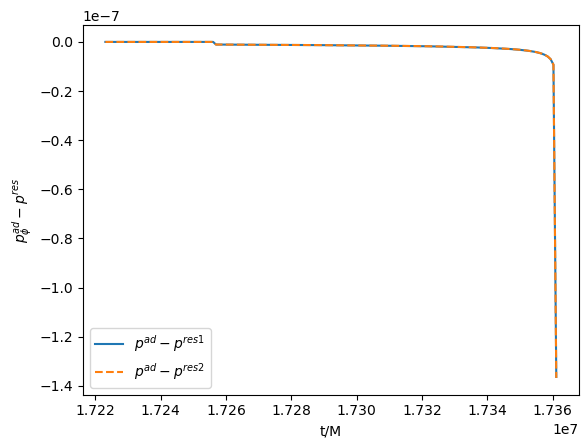

In [95]:
plt.plot(t[2*9920:],(p-pRes1)[2*9920:])
plt.plot(t[2*9920:],(p-pRes2)[2*9920:], linestyle='dashed')
plt.xlabel(r't/M');
plt.ylabel(r'$p_\phi^{ad} - p^{res}$');
plt.legend([r'$p^{ad} - p^{res1}$', r'$p^{ad} - p^{res2}$']);
plt.savefig('/Users/niels/Downloads/FEW-multiple-resonances.pdf')

In [ ]:
wav = FastKerrEccentricEquatorialFlux(inspiral_kwargs={'func':KerrEccEqFlux,'flux_output_convention':"ELQ"})

In [ ]:
wav_res = FastKerrEccentricEquatorialFlux(inspiral_kwargs={'func':KerrEccEqFlux,'resonance_handler':res, 'flux_output_convention':"ELQ"})

In [ ]:
waveform = wav(*traj_pars, dt = 10, T=T,theta=0, phi=0)

In [ ]:
waveform_res = wav_res(*traj_pars, dt = 10, T=T,theta=0, phi=0)

In [ ]:
plt.plot(waveform[:2000].real-waveform_res[:2000].real)

In [ ]:
#Why is there any difference in the plot above when the inspirals are the same until the resonance is reached

In [68]:
len(waveform)

1736112

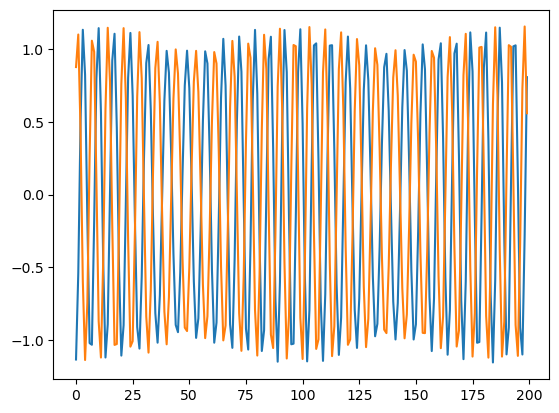

In [71]:
plt.plot(waveform[1736112-200:1736112].real)
plt.plot(waveform_res[1736112-200:1736112].real)

## Timing

In [52]:
from time import perf_counter

In [53]:
t1_start = perf_counter()
for i in np.arange(0,100):
    t, p, e, xI, Phi_phi, Phi_theta, Phi_r = traj_model(*traj_pars, T=T, upsample=True, new_t=new_T)
t1_end = perf_counter() 
print((t1_end-t1_start)/100)

0.1273138824594207


In [54]:
t1_start = perf_counter() 
for i in np.arange(0,100):
    tRes1, pRes1, eRes1, xIRes1, Phi_phiRes1, Phi_thetaRes1, Phi_rRes1 = traj_model_res1(*traj_pars, T=T, upsample=True, new_t=new_T)
t1_end = perf_counter() 
print((t1_end-t1_start)/100)

0.13643220288911834


In [55]:
t1_start = perf_counter() 
for i in np.arange(0,100):
    tRes2, pRes2, eRes2, xIRes2, Phi_phiRes2, Phi_thetaRes2, Phi_rRes2 = traj_model_res2(*traj_pars, T=T, upsample=True, new_t=new_T)
t1_end = perf_counter() 
print((t1_end-t1_start)/100)

0.12933837707154452
